<a href="https://colab.research.google.com/github/dima-kan/ITStep-AI/blob/superwised_learning/Practice_Overfitting1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [3]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
X = df.drop(columns=["price"])
y = df["price"]

In [6]:
y

,price
0,18421
1,11279
2,10279
3,9876
4,19428
...,...
4755,22285
4756,12326
4757,15603
4758,19157


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [9]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [11]:
y_pred = model.predict(X_test)
y_pred[:10]

array([11901., 22056., 14259., 23347., 31121., 20552.,  8044., 13758.,
       20140., 20687.])

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [14]:
mae

2987.089285714286

In [15]:
mse

14131208.18382353

In [16]:
r2

0.5464076446106145

# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [19]:


y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

metrics_comparison = pd.DataFrame({
    "Вибірка": ["Тренувальна", "Тестова"],
    "MAE": [train_mae, test_mae],
    "R2": [train_r2, test_r2],

})

metrics_comparison

,Вибірка,MAE,R2
0,Тренувальна,0.000000,1.000000
1,Тестова,2987.089286,0.546408


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [21]:
max_depths = range(2, 16)
train_mae = []
test_mae = []
for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_pred = tree.predict(X_train)
  test_pred = tree.predict(X_test)

  train_mae.append(mean_absolute_error(y_train, train_pred))
  test_mae.append(mean_absolute_error(y_test, test_pred))

In [22]:
test_mae

[3276.1329386307693,
 2841.451556037191,
 2582.0253313989588,
 2434.323528219818,
 2371.0694897265494,
 2346.655302754028,
 2322.2752949887613,
 2340.622518563306,
 2458.0354632561207,
 2581.0586483021857,
 2657.976336683204,
 2768.825150599981,
 2802.1984090764117,
 2861.562833776568]

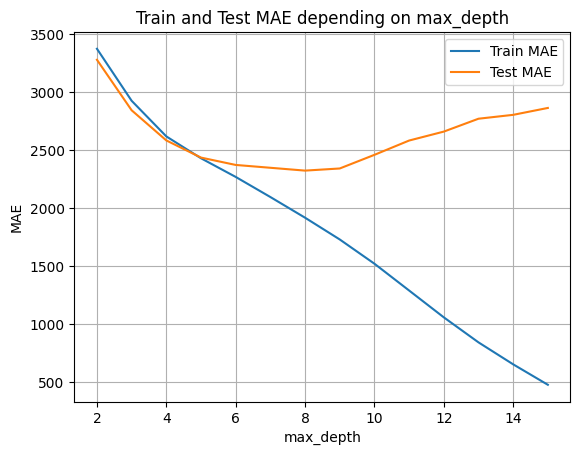

In [23]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [24]:
max_depths = range(2, 16)
train_mse = []
test_mse = []
for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_pred = tree.predict(X_train)
  test_pred = tree.predict(X_test)

  train_mse.append(mean_squared_error(y_train, train_pred))
  test_mse.append(mean_squared_error(y_test, test_pred))

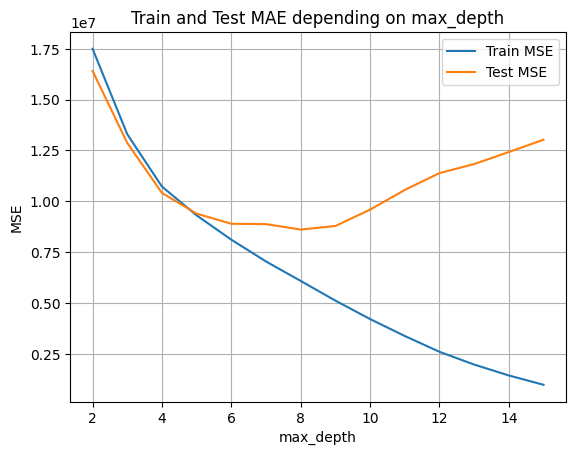

In [28]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse , label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [26]:
max_depths = range(2, 16)
train_r2 = []
test_r2 = []
for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_pred = tree.predict(X_train)
  test_pred = tree.predict(X_test)

  train_r2.append(r2_score(y_train, train_pred))
  test_r2.append(r2_score(y_test, test_pred))

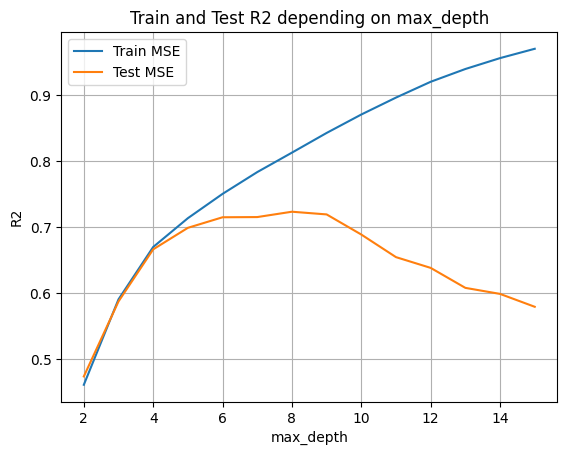

In [31]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_r2, label="Train MSE")
plt.plot(max_depths, test_r2, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()